In [29]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
# 1. LOAD DATA
file_path = "../Datasets/Training and Testing Sets/UNSW_NB15_training-set.csv"

print("Current working directory:", os.getcwd())

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Current working directory: /Users/anupam/Desktop/Final Year Project/notebooks
Dataset loaded successfully.
Dataset shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [31]:
# 2. PREPROCESSING (Ensuring data quality)

print("Preprocessing and Encoding...")

df.dropna(inplace=True)

# Convert categorical text columns into numbers
le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Preprocessing complete")

Preprocessing and Encoding...
Preprocessing complete


/var/folders/dc/m79jl7k51wg24f5l3yx_76500000gn/T/ipykernel_94118/2793927063.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [32]:
print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [33]:
# 3. SPLIT DATA

X = df.drop(['label', 'attack_cat'], axis=1)
y = df['label']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (175341, 43)
Target shape: (175341,)


In [34]:
# 80% Training / 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 140272
Testing samples: 35069


In [35]:
# 4. TRAINING (Non-LLM Technique: Random Forest)

print("Training the Defensive Model...")

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)

print("Model training complete")

Training the Defensive Model...
Model training complete


In [36]:
# 5. QUANTITATIVE EVALUATION

y_pred = clf.predict(X_test)

print("\n--- RESULTS ---")

print(classification_report(y_test, y_pred))


--- RESULTS ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     11169
           1       0.99      1.00      0.99     23900

    accuracy                           0.99     35069
   macro avg       0.99      0.98      0.99     35069
weighted avg       0.99      0.99      0.99     35069



In [37]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr = fp / (fp + tn)

print("False Positive Rate:", f"{fpr:.4%}")

False Positive Rate: 2.9277%


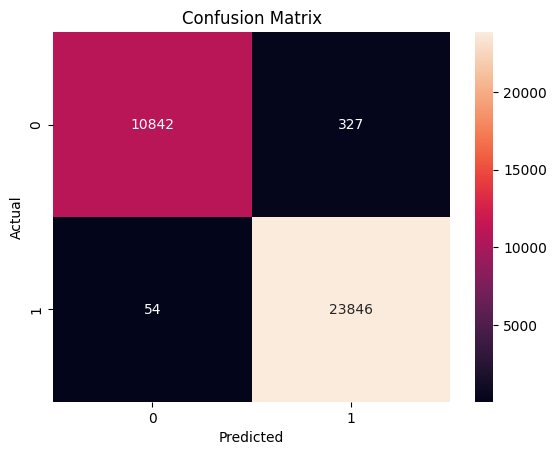

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()